In [1]:
################################################################################
#                 Convolutional Neural Networks on CIFAR-10 (PyTorch)          #
################################################################################

"""
This notebook builds and trains Convolutional Neural Networks
(CNNs) on the CIFAR-10 dataset using PyTorch. It includes:

1. Data loading and basic transformations.
2. Three CNNs (SimpleCNN, CustomCNN1, and CustomCNN2) with an optional batch normalization flag.
4. A training loop with validation and loss plotting.
5. Optional hyperparameter tuning and regularization.
6. Visualization of the first convolutional layer filters.
"""

################################################################################
#                           1. DEVICE CONFIGURATION                             #
################################################################################

# Check if GPU is available; if not, use CPU.
import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")




Using device: cuda:0


In [2]:
################################################################################
#                     2. DATA LOADING AND TRANSFORMATIONS                       #
################################################################################

"""
Define the transformations for the CIFAR-10 dataset.
Currently, only basic normalization is applied.
Random flips, crops, rotations, and other forms of variation may potentially improve model performance.
"""
import torch
import torchvision
import torchvision.transforms as transforms

transform_train = transforms.Compose([ # augmentations primarily to increase CustomCNN2 performance
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.1),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=32,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')



100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


Sample training images:


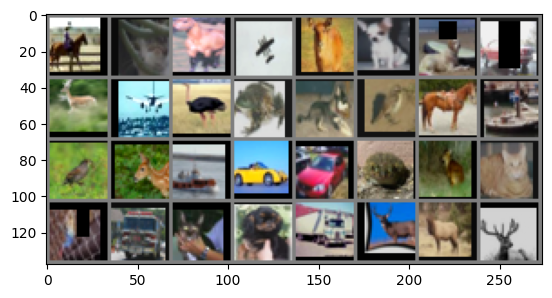

Labels: horse |   cat | horse | plane |  deer |   dog |   dog |   car |  deer | plane |  bird |  frog |   dog |  bird | horse |  ship |  bird |  deer |  ship |   car |   car |  frog |  deer |   cat |  bird | truck |   cat |   dog | truck |  deer |  deer |  deer


In [3]:
################################################################################
#                        3. EXPLORING SAMPLE DATA                              #
################################################################################

import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    """Utility function to unnormalize and display an image."""
    img = img / 2 + 0.5  # Reverse normalization for display
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Display a few training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

print("Sample training images:")
imshow(torchvision.utils.make_grid(images))
print('Labels:', ' | '.join('%5s' % classes[labels[j]] for j in range(len(labels))))



In [4]:
################################################################################
#                      4. DEFINING CNN ARCHITECTURES                            #
################################################################################

"""
We define a simple CNN (SimpleCNN) and two custom architectures
(CustomCNN1, CustomCNN2). The parameter 'use_batchnorm' toggles batch normalization
(which is optional and not required for all models).
"""

import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, use_batchnorm=False):
        super(SimpleCNN, self).__init__()
        self.use_batchnorm = use_batchnorm

        # First convolutional layer
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        if self.use_batchnorm:
            self.bn1 = nn.BatchNorm2d(16)

        # Second convolutional layer
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        if self.use_batchnorm:
            self.bn2 = nn.BatchNorm2d(32)

        # Fully connected layers
        self.fc1 = nn.Linear(8 * 8 * 32, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = x.view(-1, 8 * 8 * 32)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class CustomCNN1(nn.Module):
    def __init__(self, use_batchnorm=False):
        super(CustomCNN1, self).__init__()
        self.use_batchnorm = use_batchnorm

        # First convolutional layer
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        if (self.use_batchnorm):
          self.bn1 = nn.BatchNorm2d(32)

        # Second convolutional layer
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        if (self.use_batchnorm):
          self.bn2 = nn.BatchNorm2d(64)

        # Third convolutional layer
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        if (self.use_batchnorm):
          self.bn3 = nn.BatchNorm2d(128)

        # Pooling and dropout
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        # Fully connected layers
        self.fc1 = nn.Linear(4 * 4 * 128, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.conv1(x)
        if (self.use_batchnorm):
          x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x) # First pool

        x = self.conv2(x)
        if self.use_batchnorm:
          x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x) # Second pool

        x = self.conv3(x)
        if self.use_batchnorm:
          x = self.bn3(x)
        x = F.relu(x)
        x = self.pool(x) # Third pool

        x = x.view(-1, 4 * 4 * 128)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

class CustomCNN2(nn.Module):
    def __init__(self, use_batchnorm=False):
        super(CustomCNN2, self).__init__()
        self.use_batchnorm = use_batchnorm

        # 6 convolutional layers
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1)

        if self.use_batchnorm:
            self.bn1 = nn.BatchNorm2d(64)
            self.bn2 = nn.BatchNorm2d(128)
            self.bn3 = nn.BatchNorm2d(256)
            self.bn4 = nn.BatchNorm2d(512)
            self.bn5 = nn.BatchNorm2d(1024)
            self.bn6 = nn.BatchNorm2d(1024)

        # Pooling and dropout
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(p=0.6)

        # Fully connected layers
        self.fc1 = nn.Linear(1 * 1 * 1024, 2048)
        self.fc2 = nn.Linear(2048, 10)

    def forward(self, x):
        x = self.conv1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = F.relu(x)
        # No pooling after conv1

        x = self.conv2(x)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x) # First pool

        x = self.conv3(x)
        if self.use_batchnorm:
            x = self.bn3(x)
        x = F.relu(x)
        x = self.pool(x) # Second pool

        x = self.conv4(x)
        if self.use_batchnorm:
            x = self.bn4(x)
        x = F.relu(x)
        x = self.pool(x) # Third pool

        x = self.conv5(x)
        if self.use_batchnorm:
            x = self.bn5(x)
        x = F.relu(x)
        x = self.pool(x) # Fourth pool

        x = self.conv6(x)
        if self.use_batchnorm:
            x = self.bn6(x)
        x = F.relu(x)
        x = self.pool(x) # Fifth pool

        x = x.view(-1, 1 * 1 * 1024)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


In [5]:
################################################################################
#                5. MODEL SELECTION AND INITIALIZATION                          #
################################################################################

def get_model(model_flag, use_batchnorm=False):
    """
    Returns one of the CNN models based on 'model_flag'.
    model_flag: 1 for SimpleCNN, 2 for CustomCNN1, 3 for CustomCNN2.
    use_batchnorm: If True, includes batch normalization layers.
    """
    if model_flag == 1:
        return SimpleCNN(use_batchnorm=use_batchnorm).to(device)
    elif model_flag == 2:
        return CustomCNN1(use_batchnorm=use_batchnorm).to(device)
    elif model_flag == 3:
        return CustomCNN2(use_batchnorm=use_batchnorm).to(device)
    else:
        raise ValueError("Invalid model flag. Choose 1, 2, or 3.")



In [6]:
################################################################################
#                    6. TRAINING AND VALIDATION FUNCTIONS                       #
################################################################################

def train(net, criterion, optimizer, epochs=10):
    """
    Train the network 'net' for a given number of epochs.
    Returns lists of training and validation losses.
    """
    train_losses = []
    val_losses = []

    net.train()  # Set model to training mode
    for epoch in range(epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            optimizer.zero_grad()       # Zero the gradients
            outputs = net(inputs)       # Forward pass
            loss = criterion(outputs, labels)
            loss.backward()             # Backpropagation

            # Optional: Insert regularization techniques here (e.g., dropout is defined in the model)
            optimizer.step()            # Update parameters

            running_loss += loss.item()

        avg_train_loss = running_loss / len(trainloader)
        val_loss = validate(net, criterion)
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {avg_train_loss:.4f} | Validation Loss: {val_loss:.4f}")

    print('Finished Training')
    return train_losses, val_losses

def validate(net, criterion):
    """
    Evaluate the network on the test set.
    Returns the average validation loss.
    """
    net.eval()  # Set model to evaluation mode
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(testloader)
    accuracy = 100.0 * correct / total
    print(f"Validation Loss: {avg_val_loss:.4f}, Accuracy: {accuracy:.2f}%")
    return avg_val_loss



In [7]:
################################################################################
#                        7. PLOTTING LOSS CURVES                                #
################################################################################

def plot_losses(train_losses, val_losses):
    """
    Plots the training and validation loss curves over epochs.
    """
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()



In [8]:
################################################################################
#                      8. VISUALIZING FIRST LAYER FILTERS                      #
################################################################################

def visualize_first_layer_filters(net):
    """
    Visualizes the filters of the first convolutional layer (conv1) in the network.
    The filters are normalized to the range [0, 1] for display.
    """
    # Extract weights: shape (out_channels, in_channels, kernel_height, kernel_width)
    weights = net.conv1.weight.data.cpu().numpy()
    num_filters = weights.shape[0]

    import math
    ncols = int(math.sqrt(num_filters))
    nrows = math.ceil(num_filters / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2, nrows*2))
    axes = axes.flatten()
    for i in range(num_filters):
        # Normalize filter weights for visualization
        f = weights[i]
        f_min, f_max = f.min(), f.max()
        f = (f - f_min) / (f_max - f_min)
        # Transpose to (kernel_height, kernel_width, channels)
        f = np.transpose(f, (1, 2, 0))
        axes[i].imshow(f)
        axes[i].axis('off')
    for j in range(num_filters, len(axes)):
        axes[j].axis('off')
    plt.suptitle("First Convolutional Layer Filters")
    plt.show()



Model (flag=3, use_batchnorm=True):
 CustomCNN2(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv6): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn5): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn6): BatchNorm2d(1024, e

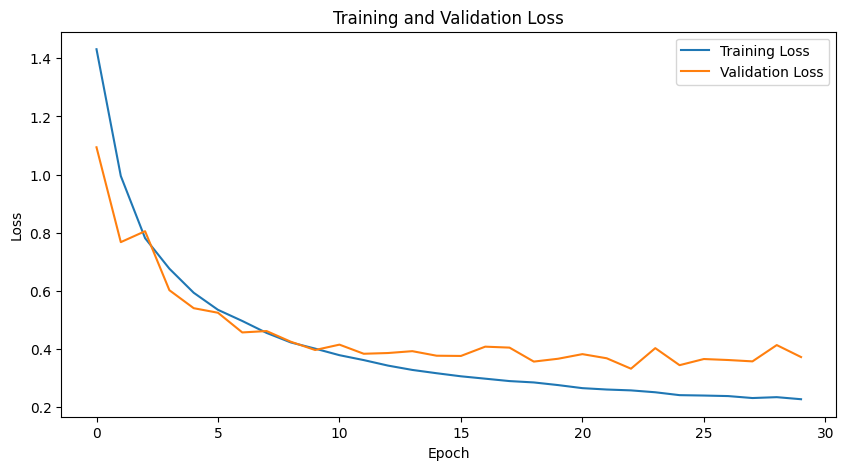


Visualizing First Layer Filters:


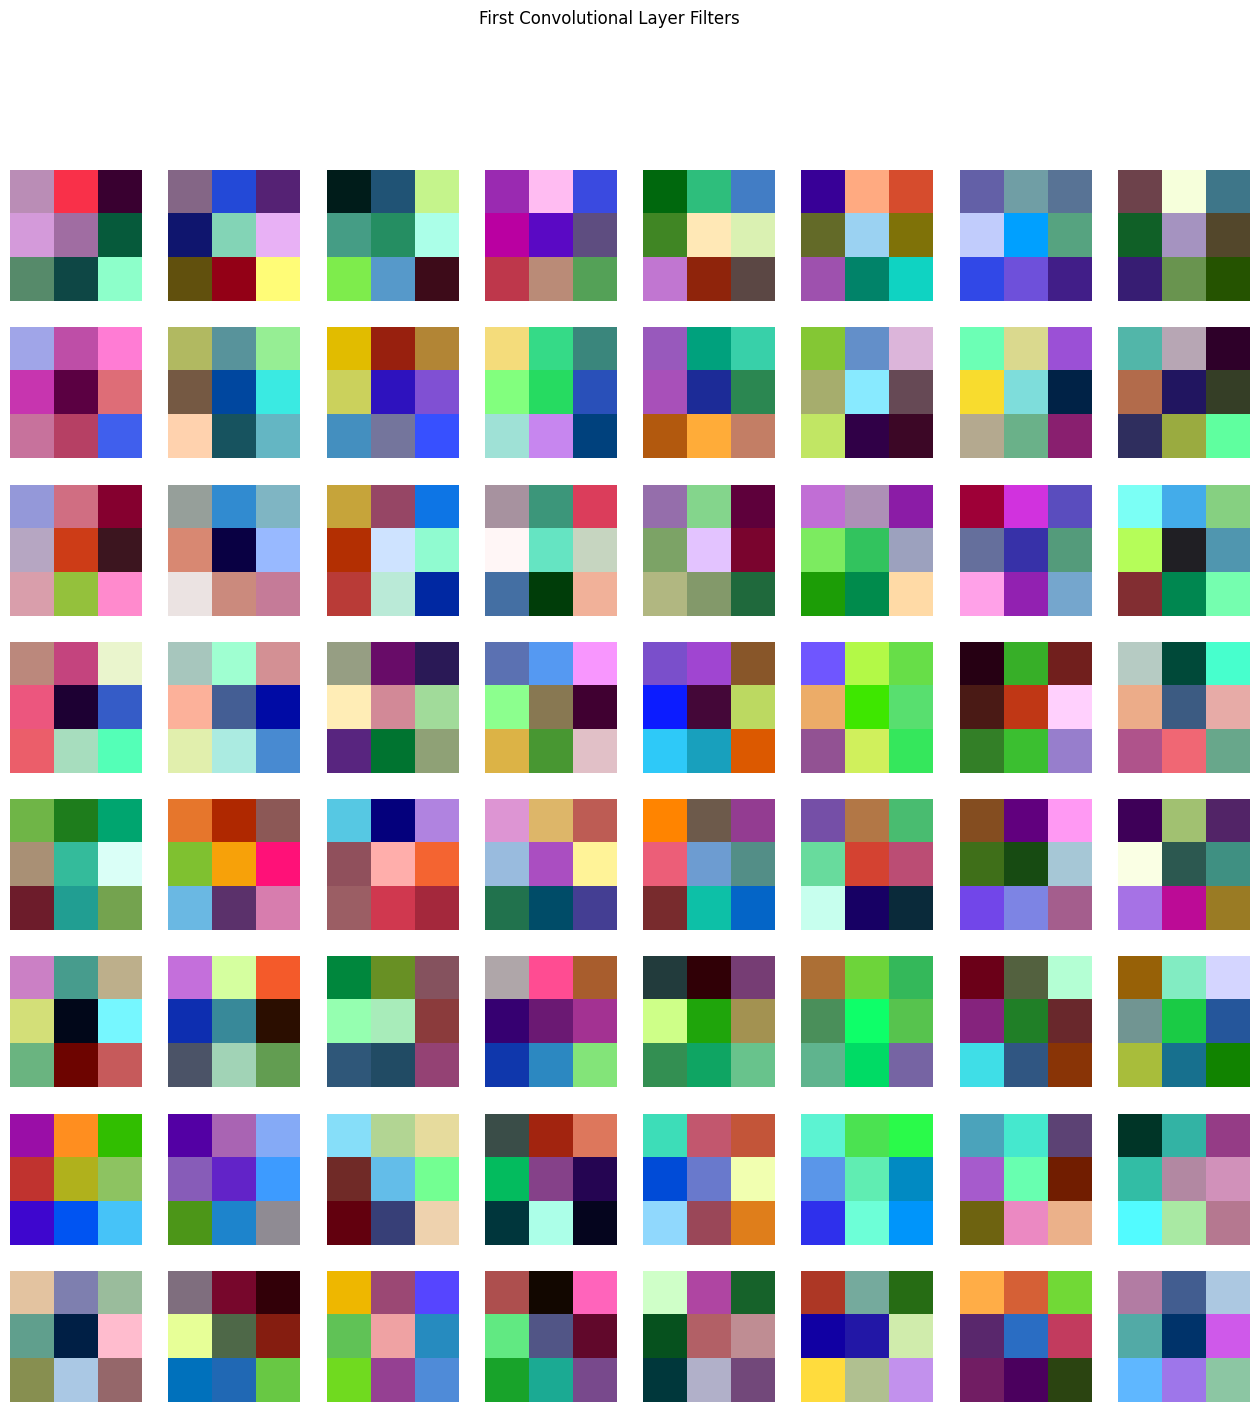


Final Test Evaluation:
Validation Loss: 0.3726, Accuracy: 88.14%


In [9]:
################################################################################
#                               9. RUN MODEL                                   #
################################################################################
import torch.optim as optim

# Model selection: set model_flag to 1 (SimpleCNN), 2 (CustomCNN1), or 3 (CustomCNN2)
model_flag = 3
# Toggle batch normalization
use_batchnorm = True

# Instantiate the chosen model
net = get_model(model_flag, use_batchnorm=use_batchnorm)
print(f"Model (flag={model_flag}, use_batchnorm={use_batchnorm}):\n", net)

# Define loss function
criterion = nn.CrossEntropyLoss()

# Optimizer and hyperparameters

# Optimizer for SimpleCNN and CustomCNN1
# optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

# For adding L2 regularization:
# optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-5)

# Optimizer for CustomCNN2
optimizer = optim.Adam(net.parameters(), lr=0.0005, weight_decay=1e-4)

# Train the model
# epochs_to_train = 10  # SimpleCNN and CustomCNN1
epochs_to_train = 30  # CustomCNN2
train_losses, val_losses = train(net, criterion, optimizer, epochs=epochs_to_train)

# Plot the training and validation loss curves
plot_losses(train_losses, val_losses)

# Visualize the first convolutional layer filters (after training)
print("\nVisualizing First Layer Filters:")
visualize_first_layer_filters(net)

# Final test evaluation
print("\nFinal Test Evaluation:")
_ = validate(net, criterion)
